In [1]:
%cd ../../

/leonardo_work/IscrC_LR4LSDS/encoderops


In [2]:
from wandb.apis.public import Api
from pathlib import Path
from datetime import datetime

from src.model import EvolutionOperator
from src.data import CalixareneDataModule
from src.configs import TrainerArgs, CalixareneDataArgs # noqa
from src.utils import get_residuals

import torch
import scipy.linalg
import numpy as np
import pandas as pd

In [3]:
runs = Api().runs(
   path="pietronvll/encoderops-calixarene-G2",
)
runs = list(runs)
ckpt_path = lambda run_id: Path(f"logs/encoderops-calixarene-G2/{run_id}/checkpoints/last.ckpt")

def check_date(date_str, cutoff_date = datetime(2025, 11, 10)):
   return datetime.strptime(date_str.rstrip('Z'), '%Y-%m-%dT%H:%M:%S.%f') > cutoff_date

@torch.no_grad()
def compute_eig_residuals(model: EvolutionOperator, reg:float=1e-4):
    if model.forecast:
        d = model.trainer_args.latent_dim + model.encoder_args["input_shape"]
    else:
        d = model.trainer_args.latent_dim
    cov_X = model.covariances.cov_X.numpy(force=True)
    cov_Y = model.covariances.cov_Y.numpy(force=True)
    regularizer = reg * np.eye(d)
    cross_cov = model.covariances.cov_XY.numpy(force=True)
    l, Q = scipy.linalg.eig(cross_cov, cov_X + regularizer)
    residuals = get_residuals(l, Q, cov_X, cov_Y, cross_cov)
    return residuals, l

In [4]:
data = {}
residuals = {}
for run in runs:
    if check_date(run.metadata['startedAt']):
        model = EvolutionOperator.load_from_checkpoint(ckpt_path(run.id))
        print(run.id)
        history = run.scan_history()
        data_run = []
        for step in history:
            data_run.append(step)
        data[model.trainer_args.latent_dim] = pd.DataFrame(data_run)
        residuals[model.trainer_args.latent_dim] = compute_eig_residuals(model)
data = sorted(data.items())
residuals = sorted(residuals.items())

a8f7oahz
i85ak5jg
mbiyf4q5
nehvck5t
nrft10go
ok78a9m5
szi4hyrh
vljvqq7d
wwr5p9op


In [5]:
latent_dims, residuals_and_eigs = list(zip(*residuals))
res, eigs = list(zip(*residuals_and_eigs))

In [6]:
import matplotlib.pyplot as plt
import matplotx
palettes = {
    "categorical_light": [
        "#6929c4",
        "#1192e8",
        "#005d5d",
        "#9f1853",
        "#fa4d56",
        "#570408",
        "#198038",
        "#002d9c",
        "#ee538b",
        "#b28600",
        "#009d9a",
        "#012749",
        "#8a3800",
        "#a56eff",
    ],
    "categorical_dark": [
        "#8a3ffc",
        "#33b1ff",
        "#007d79",
        "#ff7eb6",
        "#fa4d56",
        "#fff1f1",
        "#6fdc8c",
        "#4589ff",
        "#d12771",
        "#d2a106",
        "#08bdba",
        "#bae6ff",
        "#ba4e00",
        "#d4bbff",
    ],
    "sequential_blue": [
        "#edf5ff",
        "#d0e2ff",
        "#a6c8ff",
        "#78a9ff",
        "#4589ff",
        "#0f62fe",
        "#0043ce",
        "#002d9c",
        "#001d6c",
        "#001141",
    ],
    "sequential_purple": [
        "#f6f2ff",
        "#e8daff",
        "#d4bbff",
        "#be95ff",
        "#a56eff",
        "#8a3ffc",
        "#6929c4",
        "#491d8b",
        "#31135e",
        "#1c0f30",
    ],
    "sequential_cyan": [
        "#e5f6ff",
        "#bae6ff",
        "#82cfff",
        "#33b1ff",
        "#1192e8",
        "#0072c3",
        "#00539a",
        "#003a6d",
        "#012749",
        "#1c0f30",
    ],
    "sequential_teal": [
        "#d9fbfb",
        "#9ef0f0",
        "#3ddbd9",
        "#08bdba",
        "#009d9a",
        "#007d79",
        "#005d5d",
        "#004144",
        "#022b30",
        "#081a1c",
    ],
    "pastel": [
        "#fd7f6f",
        "#7eb0d5",
        "#b2e061",
        "#bd7ebe",
        "#ffb55a",
        "#ffee65",
        "#beb9db",
        "#fdcce5",
        "#8bd3c7",
    ],
    "bright": [
        "#e60049",
        "#0bb4ff",
        "#50e991",
        "#e6d800",
        "#9b19f5",
        "#ffa300",
        "#dc0ab4",
        "#b3d4ff",
        "#00bfa0",
    ],
}

In [13]:
sorters = [np.argsort(np.abs(eig)) for eig in eigs]
leading_residual = [error[selector[-1]] for (error, selector) in zip(res, sorters)]
leading_eig = [val[selector[-1]] for (val, selector) in zip(eigs, sorters)]

In [14]:
leading_eig

[(0.883081753057867+0j),
 (0.8768462054458596+0j),
 (0.8663992465393621+0j),
 (0.8584985153356582+0j),
 (0.8509484370676281+0j),
 (0.8562845901318158+0j),
 (0.001454229464016395+0j),
 (0.0029756457511930273+0j),
 (0.00019087334801933325+0j)]

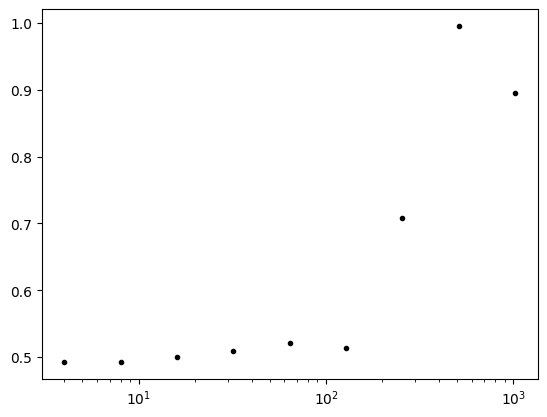

In [15]:
plt.plot(latent_dims, np.real(leading_residual), 'k.')
plt.xscale('log')


Text(0.5, 1.0, '$-\\varepsilon(\\varphi, P)$')

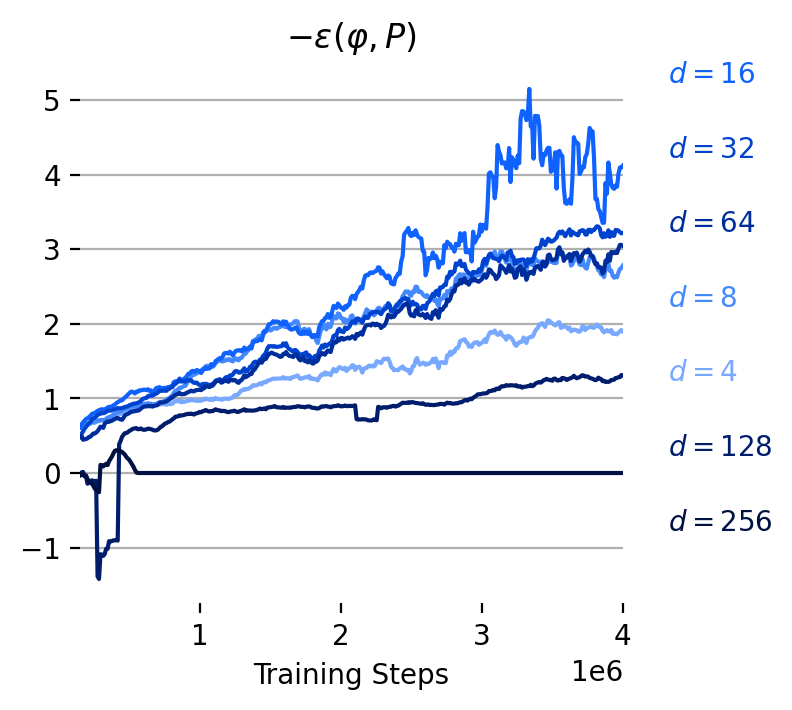

In [11]:

fig, ax = plt.subplots(figsize=(3.5,3.5), dpi=200)
for k, (feats, summary) in enumerate(data):
    if feats < 500:
        summary = summary[['train_loss_noreg', 'samples', 'tau_1_ns', 'tau_2_ns']].dropna()
        ax.plot(summary['samples'], summary['train_loss_noreg'].rolling(15).mean(), color=palettes['sequential_blue'][k + 3], label=fr"$d = {feats}$")
matplotx.line_labels(ax=ax, min_label_distance=1)
#ax.set_ylim(0, 6)
ax.margins(x=0)
ax.set_xlabel('Training Steps')
#ax.set_xticks([0, 10000, 20000], [0 , '10k', '20k'])
ax.grid(axis='y')
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_title(r'$-\varepsilon(\varphi, P)$')